# Smart AC Control — AI Training & Energy Impact Analysis

This notebook trains the AI on-off predictor and quantifies its energy/cost impact.

**Consistency note:** the AC "ground-truth" label used here is generated with the
**same physics logic** used in `RoomPhysicModeling.ipynb` (rate-of-cooling clustering +
thermodynamic override rules), instead of an independently-invented scoring heuristic.
This keeps the labeling method consistent across the whole project, so the AI model,
the physics/digital-twin work, and the energy-savings claim are all built on the same
definition of "AC ON".

**Pipeline:** `Weather_Integrated_Dataset.csv` → physics-based AC label → feature
engineering → AI training (Logistic Regression / Random Forest / XGBoost) → compare
AI controller vs a fixed-schedule baseline → energy & cost savings.


## Part 0 — Imports & Config

In [1]:
# IMPORT LIBRARIES
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


In [2]:
# PROJECT CONSTANTS
AC_POWER_KW = 2.8          # rated power draw of the AC unit while running, in kW
TARIFF_RM_PER_KWH = 0.454    # electricity tariff, RM per kWh
RESAMPLE_FREQ = "5min"      # matches the resolution used in RoomPhysicModeling.ipynb

# Environmental impact constants
# Source: TNB Grid Emission Factor, Peninsular Malaysia (~2025) = 0.574 kg CO2e/kWh
# Swap this if your competition specifies a different year/region factor.
GRID_EMISSION_FACTOR = 0.774   # kg CO2e per kWh
TREE_ABSORPTION_KG_YR = 21     # kg CO2 absorbed per mature tree per year (commonly cited estimate)
CAR_EMISSION_KG_KM = 0.12      # kg CO2 per km, average petrol car (adjust if you have a local figure)
PEAK_HOUR_START, PEAK_HOUR_END = 14, 17  # adjust to your local grid's actual peak demand window


## Part 1 — Load & Clean Dataset

Loads the weather-integrated sensor log produced by `DataAnalysis.ipynb`.


In [3]:
# LOAD DATASET
df = pd.read_csv("Weather_Integrated_Dataset.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
display(df.head())


DATASET OVERVIEW
Rows    : 10257
Columns : 12


,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-21 01:18:24,1,Sunday,1,6,30.8,72.3,27.595001,83.465576,0.0,88.200000,2.199785
1,2026-06-21 01:18:26,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.200000,2.199785
2,2026-06-21 01:18:28,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.200000,2.199785
3,2026-06-21 01:18:30,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.200000,2.199785
4,2026-06-21 01:18:32,1,Sunday,1,6,30.8,72.4,27.630835,83.283875,0.0,87.933334,2.185981


In [4]:
# DATA CLEANING
df = df.drop_duplicates()
df = df.sort_values("Datetime").reset_index(drop=True)

print("Missing Values")
display(df.isnull().sum())


Missing Values


Datetime           0
Hour               0
DayName            0
Weekend            0
DayOfWeek          0
IndoorTemp         0
IndoorHumidity     0
OutdoorTemp        0
OutdoorHumidity    0
Rain               0
CloudCover         0
WindSpeed          0
dtype: int64

## Part 2 — Physics-Based AC State Labeling (Ground Truth)

Raw sensor readings are noisy at 1-minute resolution, so — exactly as in
`RoomPhysicModeling.ipynb` — we resample to **5-minute** averages first, then derive
the AC ON/OFF label from real thermodynamic behaviour rather than an arbitrary score:

1. Rate-of-change features: `dT`, `dH` (how fast indoor temp/humidity are moving) and
   `Gradient` (outdoor − indoor temp).
2. K-Means (2 clusters) is run **only** during hours where AC use is genuinely
   ambiguous, to make an initial ON/OFF guess based on cooling behaviour.
3. Physics override rules replace the ML guess whenever the thermodynamics are
   unambiguous:
   - Indoor colder than outdoor by a real margin *and* not warming → must be AC.
   - A cooling rate that fast can't happen without mechanical cooling → AC ON.
   - Indoor temperature actively rising → AC is definitely OFF, regardless of cluster.
4. A short rolling-median smooths out flicker from sensor noise.

Using the identical method as the physics/digital-twin notebook means the label your
AI model learns to predict is the **same physical definition of "AC ON"** used
elsewhere in the project — this is the main fix versus the previous version, which
trained on an independently-invented weighted confidence score.


In [5]:
# RESAMPLE TO 5-MINUTE INTERVALS
df = df.set_index("Datetime")

numerical_cols = [
    "IndoorTemp", "IndoorHumidity",
    "OutdoorTemp", "OutdoorHumidity",
    "Rain", "CloudCover", "WindSpeed"
]
df_r = df[numerical_cols].resample(RESAMPLE_FREQ).mean().dropna()

# Rebuild calendar features on the new resolution
df_r["Hour"] = df_r.index.hour
df_r["DayOfWeek"] = df_r.index.dayofweek
df_r["DayName"] = df_r.index.day_name()
df_r["Weekend"] = (df_r["DayOfWeek"] >= 5).astype(int)
df_r = df_r.reset_index()

print("Resampled Shape:", df_r.shape)
display(df_r.head())


Resampled Shape: (2050, 12)


,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,Hour,DayOfWeek,DayName,Weekend
0,2026-06-21 01:15:00,30.804348,72.523913,27.637067,83.252274,0.0,87.886956,2.183580,1,6,Sunday,1
1,2026-06-21 01:25:00,31.000000,71.400000,27.989168,81.466860,0.0,85.266670,2.047937,1,6,Sunday,1
2,2026-06-21 01:30:00,30.800000,72.200000,28.042918,81.194310,0.0,84.866665,2.027230,1,6,Sunday,1
3,2026-06-21 13:00:00,31.625000,74.150000,26.733334,85.875866,0.0,42.541666,6.164891,13,6,Sunday,1
4,2026-06-21 13:05:00,32.000000,73.220000,26.703333,85.757584,0.0,43.516666,6.331798,13,6,Sunday,1


In [6]:
# RATE-OF-CHANGE / THERMODYNAMIC FEATURES
df_r["dT"] = df_r["IndoorTemp"].diff().fillna(0)
df_r["dH"] = df_r["IndoorHumidity"].diff().fillna(0)
df_r["Gradient"] = df_r["OutdoorTemp"] - df_r["IndoorTemp"]


In [7]:
# STEP 1 — INITIAL ML GUESS (K-MEANS ON AMBIGUOUS HOURS)
df_r["AC_State"] = 0

active_days = df_r["DayOfWeek"].isin([0, 1, 2, 3, 4])   # adjust to your actual occupancy pattern
active_hours = (df_r["Hour"] >= 9) & (df_r["Hour"] < 18)
uncertain_mask = active_days & active_hours

uncertain_data = df_r[uncertain_mask].copy()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_features = ["dT", "dH", "Gradient"]
uncertain_data["cluster"] = kmeans.fit_predict(uncertain_data[cluster_features])

# The AC-ON cluster is the one with the steepest (most negative) temperature trend
on_cluster_index = np.argmin(kmeans.cluster_centers_[:, 0])
uncertain_data["Predicted_AC"] = (uncertain_data["cluster"] == on_cluster_index).astype(int)

df_r.loc[uncertain_mask, "AC_State"] = uncertain_data["Predicted_AC"]


In [8]:
# STEP 2 — PHYSICS OVERRIDES (same thresholds as RoomPhysicModeling.ipynb)
# Override A: room colder than outside by a real margin and not warming -> must be AC
is_colder_than_outside = df_r["IndoorTemp"] < (df_r["OutdoorTemp"] - 2.5)
is_not_warming = df_r["dT"] <= 0.05
temp_override = is_colder_than_outside & is_not_warming

# Override B: a cooling rate this fast is not physically possible without mechanical cooling
cooling_override = df_r["dT"] < -0.15

df_r.loc[temp_override | cooling_override, "AC_State"] = 1

# Override C: temperature actively rising -> AC is definitely off
warming_override = df_r["dT"] > 0.05
df_r.loc[warming_override, "AC_State"] = 0


In [9]:
# STEP 3 — SMOOTHING (remove flicker)
df_r["AC_State"] = df_r["AC_State"].rolling(window=7, center=True).median()
df_r["AC_State"] = df_r["AC_State"].fillna(0).astype(int)

print("Physics-Derived AC State Distribution")
print(df_r["AC_State"].value_counts())


Physics-Derived AC State Distribution
AC_State
0    1430
1     620
Name: count, dtype: int64


In [10]:
# SANITY CHECK — ON-CYCLE DIAGNOSTICS
# Confirms the label behaves like a real AC (sensible cycle length & temperature drop),
# not just an artifact of the thresholds.
check = df_r.copy()
check["Cycle_ID"] = (check["AC_State"] != check["AC_State"].shift()).cumsum()
on_cycles = check[check["AC_State"] == 1]

diagnostics = on_cycles.groupby("Cycle_ID").agg(
    Start_Time=("Datetime", "first"),
    End_Time=("Datetime", "last"),
    Start_Temp=("IndoorTemp", "first"),
    End_Temp=("IndoorTemp", "last"),
)
diagnostics["Duration_Minutes"] = (
    (diagnostics["End_Time"] - diagnostics["Start_Time"]).dt.seconds / 60 + 5
)
diagnostics["Temp_Drop"] = diagnostics["Start_Temp"] - diagnostics["End_Temp"]

print(f"Average Cycle Duration : {diagnostics['Duration_Minutes'].mean():.1f} min")
print(f"Average Deadband       : {diagnostics['Temp_Drop'].mean():.1f} degC")
display(diagnostics.head())


Average Cycle Duration : 194.1 min
Average Deadband       : 2.1 degC


,Start_Time,End_Time,Start_Temp,End_Temp,Duration_Minutes,Temp_Drop
Cycle_ID,,,,,,
2,2026-06-22 11:40:00,2026-06-22 14:45:00,25.925,24.04,190.0,1.885
4,2026-06-22 15:30:00,2026-06-22 17:15:00,25.700,24.44,110.0,1.260
6,2026-06-22 20:30:00,2026-06-22 21:25:00,30.440,25.30,60.0,5.140
8,2026-06-23 04:45:00,2026-06-23 07:10:00,29.400,29.30,150.0,0.100
10,2026-06-24 09:45:00,2026-06-24 12:10:00,30.200,25.30,150.0,4.900


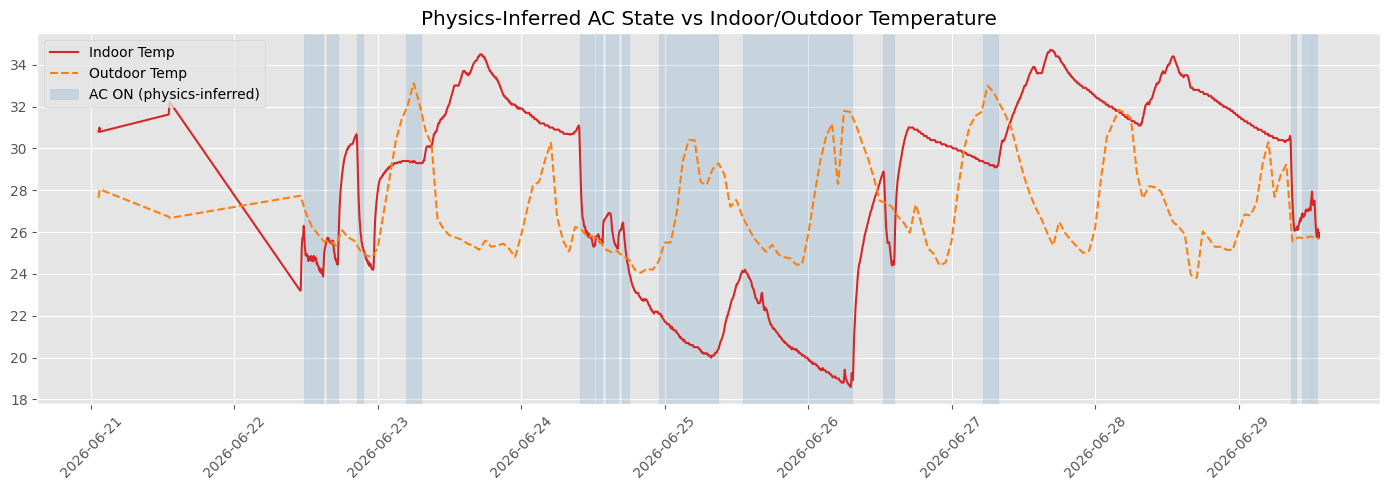

In [11]:
# VISUALIZE INFERRED AC STATE
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df_r["Datetime"], df_r["IndoorTemp"], color="tab:red", label="Indoor Temp")
ax1.plot(df_r["Datetime"], df_r["OutdoorTemp"], color="tab:orange", linestyle="--", label="Outdoor Temp")
ax1.fill_between(
    df_r["Datetime"], 0, 1,
    where=(df_r["AC_State"] == 1),
    color="tab:blue", alpha=0.15, transform=ax1.get_xaxis_transform(),
    label="AC ON (physics-inferred)"
)
ax1.set_title("Physics-Inferred AC State vs Indoor/Outdoor Temperature")
ax1.tick_params(axis="x", rotation=45)
ax1.legend(loc="upper left")
plt.tight_layout()
plt.show()


## Part 3 — Feature Engineering for the AI Model

Same physics-motivated feature set as before (temp/humidity differences, cooling
rate, lags, rolling stats), just computed on the 5-minute-resolution, physics-labeled
dataframe so training features and label are on the same time base.


In [12]:
df_r["TempDifference"] = df_r["IndoorTemp"] - df_r["OutdoorTemp"]
df_r["HumidityDifference"] = df_r["IndoorHumidity"] - df_r["OutdoorHumidity"]
df_r["CoolingRate"] = -df_r["dT"]  # positive = actively cooling

# Lags & short-term memory (1 step = 5 min at this resolution)
df_r["IndoorTemp_Lag1"] = df_r["IndoorTemp"].shift(1)
df_r["IndoorHumidity_Lag1"] = df_r["IndoorHumidity"].shift(1)
df_r["RollingTemp_1hr"] = df_r["IndoorTemp"].rolling(window=12).mean()
df_r["RollingHumidity_1hr"] = df_r["IndoorHumidity"].rolling(window=12).mean()
df_r["TempStd_1hr"] = df_r["IndoorTemp"].rolling(window=12).std()

df_r = df_r.dropna().reset_index(drop=True)
display(df_r.head())


,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,Hour,DayOfWeek,DayName,Weekend,dT,dH,Gradient,AC_State,TempDifference,HumidityDifference,CoolingRate,IndoorTemp_Lag1,IndoorHumidity_Lag1,RollingTemp_1hr,RollingHumidity_1hr,TempStd_1hr
0,2026-06-22 11:30:00,25.900,68.60,27.342499,83.626135,0.0,99.491665,5.105210,11,0,Monday,0,0.150,0.95,1.442499,0,-1.442499,-15.026135,-0.150,25.750,67.65,28.124529,71.533659,3.560625
1,2026-06-22 11:35:00,26.300,68.10,27.237500,84.548504,0.0,99.375000,5.101878,11,0,Monday,0,0.400,-0.50,0.937500,0,-0.937500,-16.448504,-0.400,25.900,68.60,27.749167,71.165000,3.489142
2,2026-06-22 11:40:00,25.925,66.30,27.177499,85.075574,0.0,99.308333,5.099974,11,0,Monday,0,-0.375,-1.80,1.252499,1,-1.252499,-18.775574,0.375,26.300,68.10,27.326250,70.740000,3.364637
3,2026-06-22 11:45:00,25.350,63.55,27.072500,85.997951,0.0,99.191667,5.096642,11,0,Monday,0,-0.575,-2.75,1.722500,1,-1.722500,-22.447951,0.575,25.925,66.30,26.872083,70.019167,3.217735
4,2026-06-22 11:50:00,25.120,64.44,27.005000,86.590905,0.0,99.116667,5.094500,11,0,Monday,0,-0.230,0.89,1.885000,1,-1.885000,-22.150905,0.230,25.350,63.55,26.330000,69.210000,2.873790


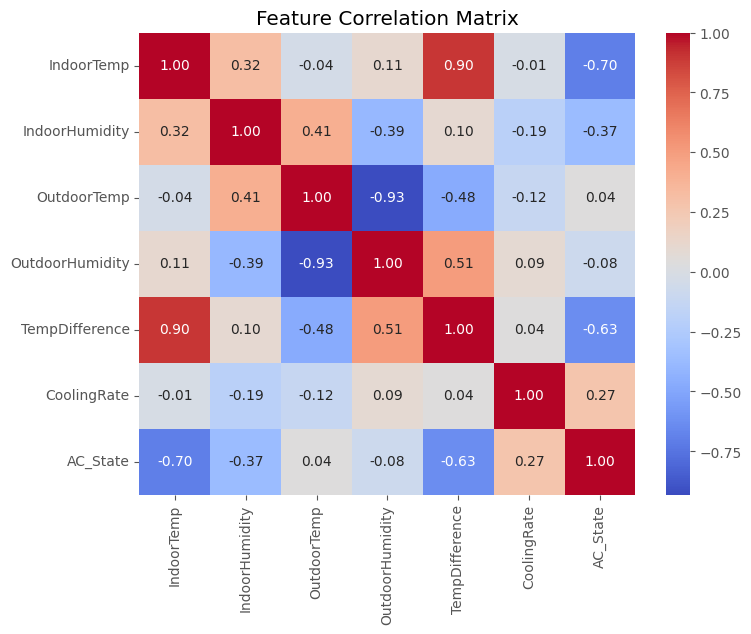

In [13]:
# CORRELATION CHECK
corr_cols = [
    "IndoorTemp", "IndoorHumidity", "OutdoorTemp", "OutdoorHumidity",
    "TempDifference", "CoolingRate", "AC_State"
]
plt.figure(figsize=(8, 6))
sns.heatmap(df_r[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


## Part 4 — Chronological Train/Test Split

This is time-series data with lag/rolling features, so a random `stratify` split (used
in the previous version) risks leaking future information into training. We split
**chronologically** instead — train on the earlier period, test on the later period —
and use `TimeSeriesSplit` for cross-validation for the same reason.


In [14]:
FEATURES = [
    "Hour", "Weekend",
    "IndoorTemp", "IndoorHumidity", "OutdoorTemp", "OutdoorHumidity",
    "Rain", "CloudCover", "WindSpeed",
    "TempDifference", "HumidityDifference", "CoolingRate",
    "IndoorTemp_Lag1", "IndoorHumidity_Lag1",
    "RollingTemp_1hr", "RollingHumidity_1hr", "TempStd_1hr"
]
X = df_r[FEATURES]
y = df_r["AC_State"]

split_idx = int(len(df_r) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)
print(f"Train period : {df_r['Datetime'].iloc[0]} -> {df_r['Datetime'].iloc[split_idx-1]}")
print(f"Test period  : {df_r['Datetime'].iloc[split_idx]} -> {df_r['Datetime'].iloc[-1]}")


Training Set : (1631, 17)
Testing Set  : (408, 17)
Train period : 2026-06-22 11:30:00 -> 2026-06-28 03:25:00
Test period  : 2026-06-28 03:30:00 -> 2026-06-29 13:25:00


## Part 5 — AI Model Training & Comparison

In [15]:
# TRAIN MODELS
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred, lr_prob = lr.predict(X_test), lr.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred, rf_prob = rf.predict(X_test), rf.predict_proba(X_test)[:, 1]

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    random_state=42, eval_metric="logloss"
)
xgb.fit(X_train, y_train)
xgb_pred, xgb_prob = xgb.predict(X_test), xgb.predict_proba(X_test)[:, 1]

models = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}
predictions = {
    "Logistic Regression": (lr_pred, lr_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob),
}


In [16]:
# MODEL PERFORMANCE COMPARISON
rows = []
for name, (pred, prob) in predictions.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob),
    })
performance = pd.DataFrame(rows)
display(performance.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.9240,0.8000,0.3721,0.5079,0.9044
1,Random Forest,0.9387,0.7647,0.6047,0.6753,0.9814
2,XGBoost,0.9510,0.8108,0.6977,0.7500,0.9831


In [17]:
# SELECT BEST MODEL (by ROC AUC on the held-out, chronologically-later test set)
best_model_name = performance.loc[performance["ROC AUC"].idxmax(), "Model"]
best_model = models[best_model_name]
best_pred, best_prob = predictions[best_model_name]
print(f"Best Model: {best_model_name}")


Best Model: XGBoost


In [18]:
# CROSS VALIDATION (time-series aware — no shuffling, no leakage)
tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=tscv, scoring="accuracy")
    cv_rows.append([name, scores.mean(), scores.std()])
cv_results = pd.DataFrame(cv_rows, columns=["Model", "Mean Accuracy", "Std Dev"])
display(cv_results.round(4))


,Model,Mean Accuracy,Std Dev
0,Logistic Regression,0.8053,0.1615
1,Random Forest,0.7982,0.2745
2,XGBoost,0.8478,0.1859


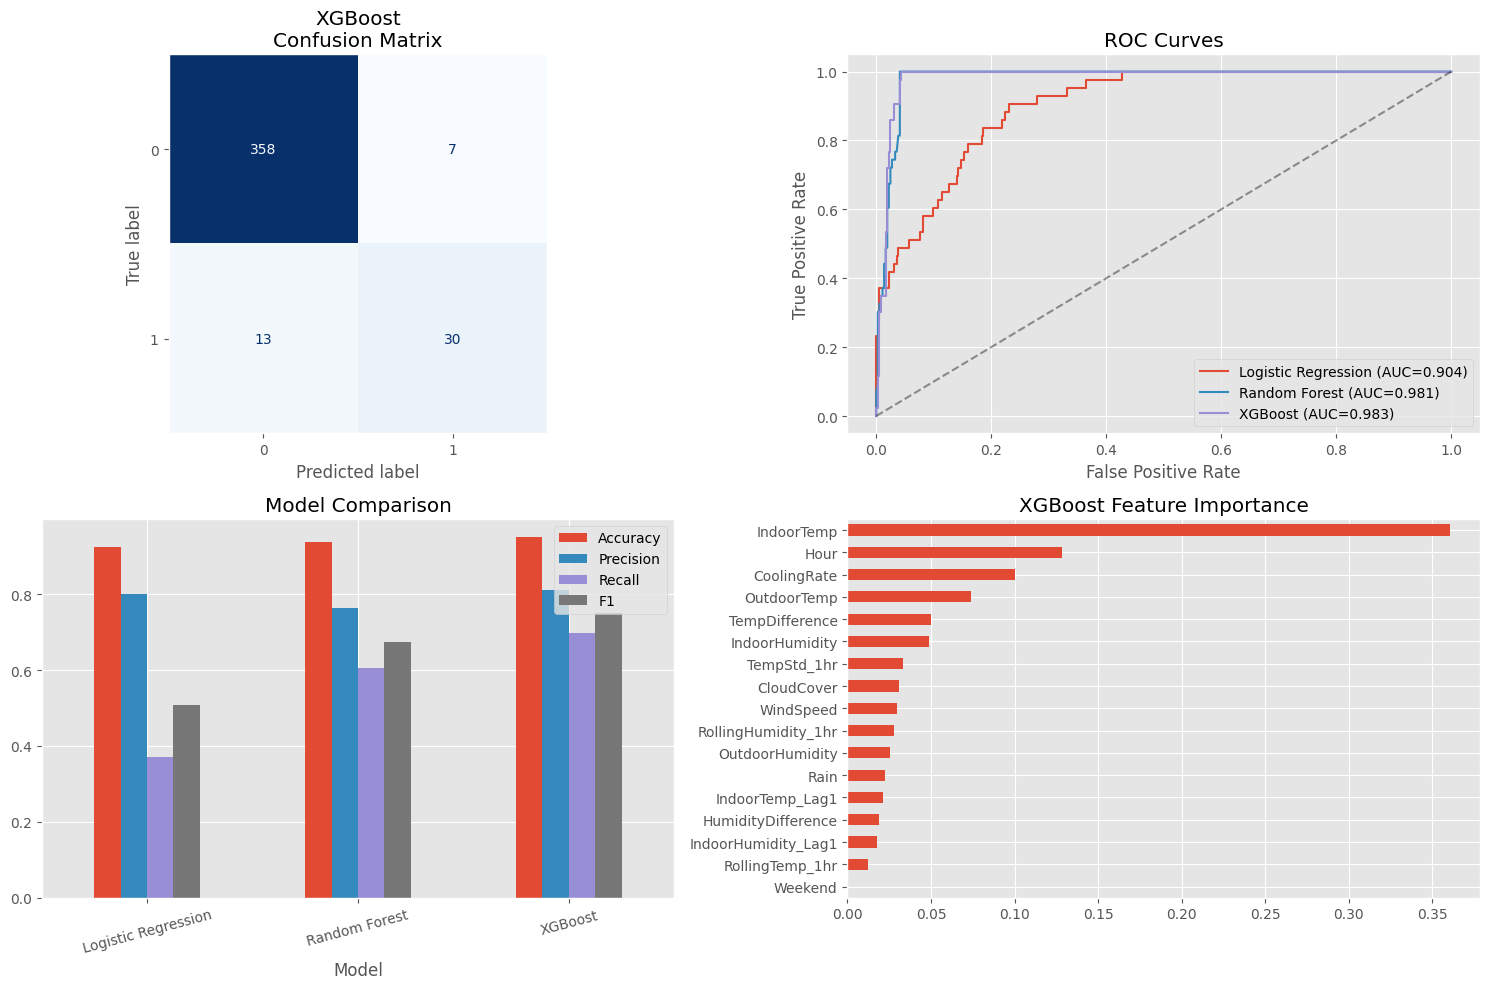

In [27]:
# EVALUATION DASHBOARD
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, cmap="Blues", colorbar=False, values_format="d", ax=ax[0, 0]
)
ax[0, 0].set_title(f"{best_model_name}\nConfusion Matrix")
ax[0, 0].grid(False)

for name, (pred, prob) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax[0, 1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
ax[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0, 1].set_title("ROC Curves")
ax[0, 1].set_xlabel("False Positive Rate")
ax[0, 1].set_ylabel("True Positive Rate")
ax[0, 1].legend()

performance.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot.bar(ax=ax[1, 0])
ax[1, 0].set_title("Model Comparison")
ax[1, 0].tick_params(axis="x", rotation=15)

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    importances.plot.barh(ax=ax[1, 1])
    ax[1, 1].set_title(f"{best_model_name} Feature Importance")
else:
    ax[1, 1].axis("off")

plt.tight_layout()
plt.show()


In [20]:
# SAVE MODEL
joblib.dump(best_model, "SmartHVAC_Model.pkl")
joblib.dump(FEATURES, "feature_columns.pkl")
print("Model saved successfully.")


Model saved successfully.


## Part 6 — AI Prediction for the Full Dataset

In [21]:
df_r["AI_AC"] = best_model.predict(X)
df_r["AI_Probability"] = (best_model.predict_proba(X)[:, 1] * 100).round(2)
display(df_r[["Datetime", "AC_State", "AI_AC", "AI_Probability"]].head())


,Datetime,AC_State,AI_AC,AI_Probability
0,2026-06-22 11:30:00,0,0,9.070000
1,2026-06-22 11:35:00,0,0,6.430000
2,2026-06-22 11:40:00,1,1,99.389999
3,2026-06-22 11:45:00,1,1,99.720001
4,2026-06-22 11:50:00,1,1,99.820000


## Part 7 — Baseline Controller vs AI Controller

**Baseline** = a simple fixed-schedule rule-based controller (e.g. AC on 8am-8pm),
representing how the room is likely operated today without any smart control.
**AI controller** = the trained model's predicted schedule.

Both are evaluated over the **same period and at the same 5-minute resolution**, so the
runtime comparison is apples-to-apples. `SAMPLE_MINUTES` and `Baseline_AC` defined here
are reused by every calculation in Part 8, so there's a single source of truth for the
comparison instead of scattered assumptions.


In [22]:
# BASELINE CONTROLLER — adjust the hours to match your actual site's current schedule
SAMPLE_MINUTES = 5  # data is at 5-minute resolution after resampling in Part 2

df_r["Baseline_AC"] = np.where((df_r["Hour"] >= 8) & (df_r["Hour"] < 20), 1, 0)

baseline_runtime_hr = df_r["Baseline_AC"].sum() * SAMPLE_MINUTES / 60
ai_runtime_hr = df_r["AI_AC"].sum() * SAMPLE_MINUTES / 60
data_span_days = (df_r["Datetime"].iloc[-1] - df_r["Datetime"].iloc[0]).total_seconds() / 86400

print(f"Baseline Runtime   : {baseline_runtime_hr:.2f} hours")
print(f"AI Runtime         : {ai_runtime_hr:.2f} hours")
print(f"Observation window : {data_span_days:.1f} days")


Baseline Runtime   : 85.92 hours
AI Runtime         : 51.17 hours
Observation window : 7.1 days


## Part 8 — Energy, Cost & Environmental Impact

Everything here is computed once, in order, into a single set of variables — then
reported through **one** summary table and **one** dashboard at the end, so the story
reads top-to-bottom: runtime → energy → cost → CO2 → relatable equivalents → peak-demand
benefit → the full picture.


In [23]:
# --- 8.1 Energy consumption ---
baseline_energy_kwh = baseline_runtime_hr * AC_POWER_KW
ai_energy_kwh = ai_runtime_hr * AC_POWER_KW
energy_saved_kwh = baseline_energy_kwh - ai_energy_kwh
energy_saving_pct = (energy_saved_kwh / baseline_energy_kwh) * 100

# --- 8.2 Electricity cost ---
baseline_cost = baseline_energy_kwh * TARIFF_RM_PER_KWH
ai_cost = ai_energy_kwh * TARIFF_RM_PER_KWH
cost_saved = baseline_cost - ai_cost

# --- 8.3 CO2 avoided ---
co2_avoided_kg = energy_saved_kwh * GRID_EMISSION_FACTOR

# --- 8.4 Relatable equivalents (for a competition pitch, not precise measurements) ---
trees_equivalent = co2_avoided_kg / TREE_ABSORPTION_KG_YR
km_not_driven_equivalent = co2_avoided_kg / CAR_EMISSION_KG_KM

# --- 8.5 Peak-hour demand reduction (business-relevant: utilities/landlords care about this) ---
peak_mask = (df_r["Hour"] >= PEAK_HOUR_START) & (df_r["Hour"] < PEAK_HOUR_END)
baseline_peak_hr = df_r.loc[peak_mask, "Baseline_AC"].sum() * SAMPLE_MINUTES / 60
ai_peak_hr = df_r.loc[peak_mask, "AI_AC"].sum() * SAMPLE_MINUTES / 60
peak_reduction_pct = (1 - ai_peak_hr / baseline_peak_hr) * 100 if baseline_peak_hr > 0 else 0

# --- 8.6 Annualized projection (extrapolated from the observation window, clearly labeled) ---
yearly_factor = 365 / data_span_days if data_span_days > 0 else 0
projected_yearly_cost_saved = cost_saved * yearly_factor
projected_yearly_co2_avoided_tonnes = (co2_avoided_kg * yearly_factor) / 1000

print("All impact metrics calculated — see summary table and dashboard below.")


All impact metrics calculated — see summary table and dashboard below.


In [24]:
# SUMMARY TABLE — the single reference table for the whole impact story
summary = pd.DataFrame({
    "Metric": [
        "AC Runtime (hours)",
        "Energy Consumption (kWh)",
        "Electricity Cost (RM)",
        "CO2 Emissions (kg)",
    ],
    "Baseline": [
        round(baseline_runtime_hr, 2),
        round(baseline_energy_kwh, 2),
        round(baseline_cost, 2),
        round(baseline_energy_kwh * GRID_EMISSION_FACTOR, 2),
    ],
    "AI Controller": [
        round(ai_runtime_hr, 2),
        round(ai_energy_kwh, 2),
        round(ai_cost, 2),
        round(ai_energy_kwh * GRID_EMISSION_FACTOR, 2),
    ],
})
summary["Savings"] = [
    round(baseline_runtime_hr - ai_runtime_hr, 2),
    round(energy_saved_kwh, 2),
    round(cost_saved, 2),
    round(co2_avoided_kg, 2),
]
summary["Savings %"] = [
    round((1 - ai_runtime_hr / baseline_runtime_hr) * 100, 1),
    round(energy_saving_pct, 1),
    round((cost_saved / baseline_cost) * 100, 1),
    round((co2_avoided_kg / (baseline_energy_kwh * GRID_EMISSION_FACTOR)) * 100, 1),
]
display(summary)

print(f"\nRelatable equivalents (rough estimates, for context — not precise measurements):")
print(f"  - {trees_equivalent:.1f} tree-years of CO2 absorption")
print(f"  - {km_not_driven_equivalent:.0f} km not driven in an average petrol car")
print(f"\nPeak-hour ({PEAK_HOUR_START}:00-{PEAK_HOUR_END}:00) AC runtime reduction: {peak_reduction_pct:.1f}%")
print(f"\nProjected over a full year (extrapolated from {data_span_days:.1f} observed days):")
print(f"  - Cost saved      : RM {projected_yearly_cost_saved:.2f}")
print(f"  - CO2 avoided     : {projected_yearly_co2_avoided_tonnes:.3f} tonnes")


,Metric,Baseline,AI Controller,Savings,Savings %
0,AC Runtime (hours),85.92,51.17,34.75,40.4
1,Energy Consumption (kWh),240.57,143.27,97.30,40.4
2,Electricity Cost (RM),109.22,65.04,44.17,40.4
3,CO2 Emissions (kg),186.20,110.89,75.31,40.4



Relatable equivalents (rough estimates, for context — not precise measurements):
  - 3.6 tree-years of CO2 absorption
  - 628 km not driven in an average petrol car

Peak-hour (14:00-17:00) AC runtime reduction: 62.3%

Projected over a full year (extrapolated from 7.1 observed days):
  - Cost saved      : RM 2277.39
  - CO2 avoided     : 3.883 tonnes


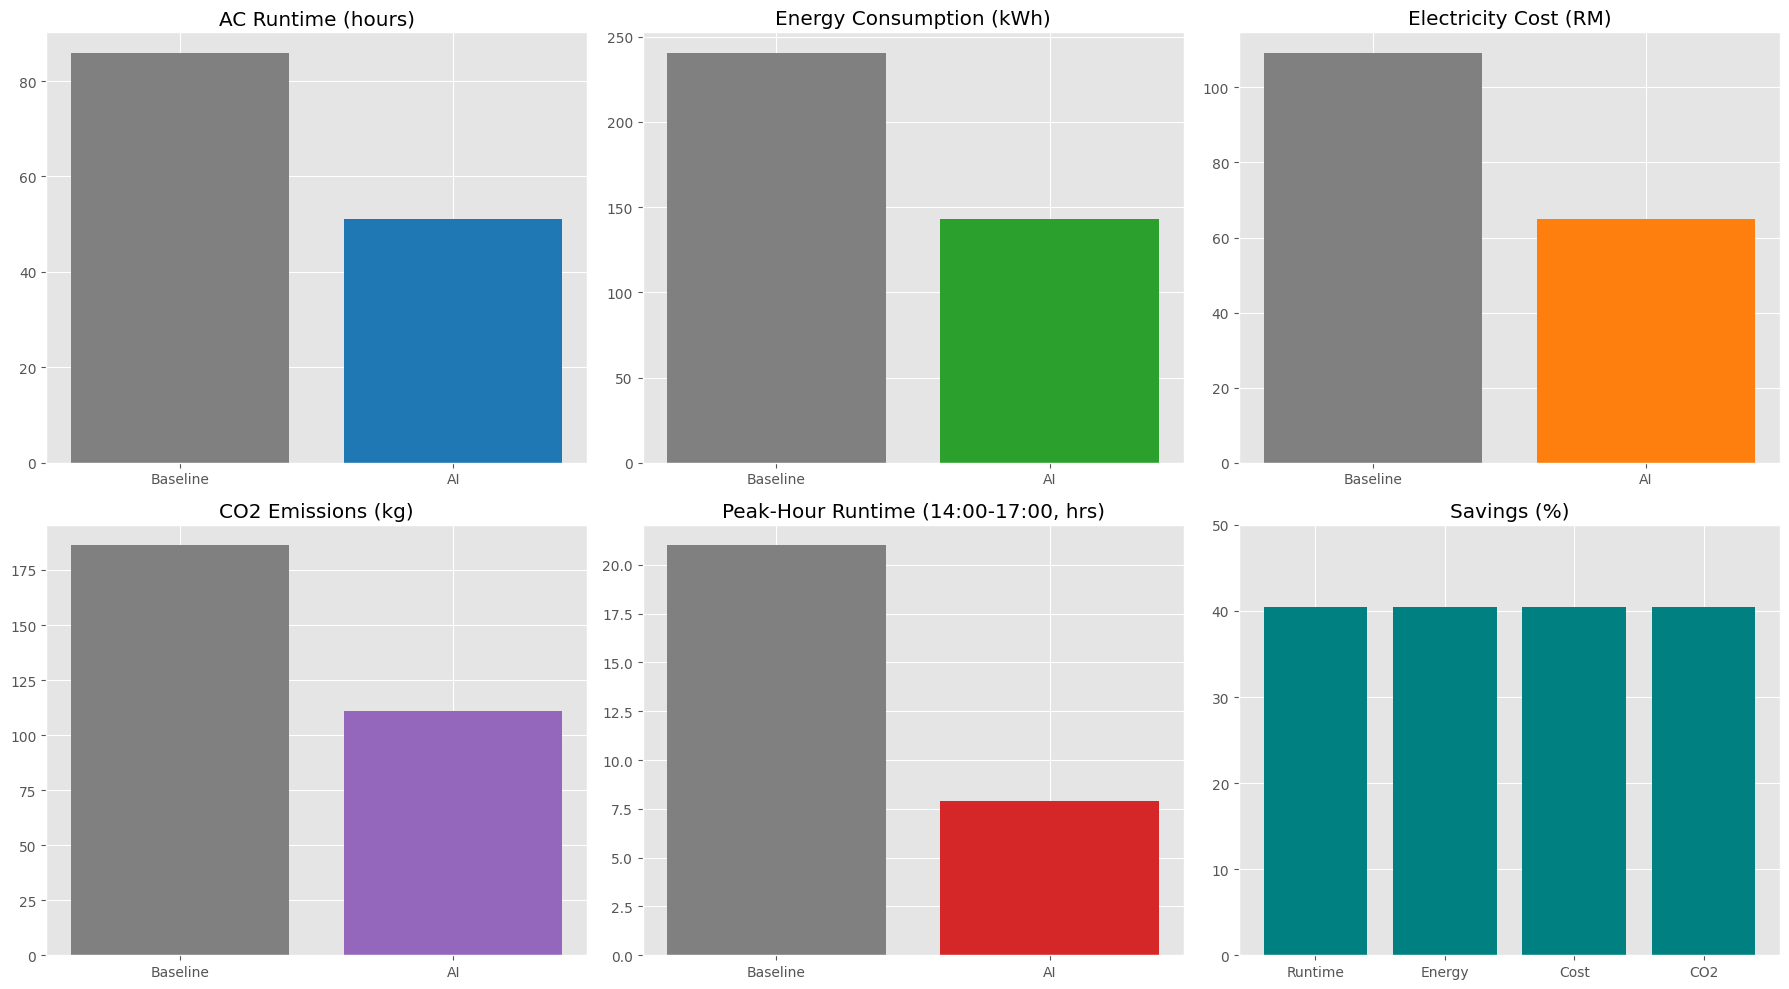

In [25]:
# IMPACT DASHBOARD — one figure, one coherent read
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].bar(["Baseline", "AI"], [baseline_runtime_hr, ai_runtime_hr], color=["gray", "tab:blue"])
ax[0, 0].set_title("AC Runtime (hours)")

ax[0, 1].bar(["Baseline", "AI"], [baseline_energy_kwh, ai_energy_kwh], color=["gray", "tab:green"])
ax[0, 1].set_title("Energy Consumption (kWh)")

ax[0, 2].bar(["Baseline", "AI"], [baseline_cost, ai_cost], color=["gray", "tab:orange"])
ax[0, 2].set_title("Electricity Cost (RM)")

ax[1, 0].bar(["Baseline", "AI"],
             [baseline_energy_kwh * GRID_EMISSION_FACTOR, ai_energy_kwh * GRID_EMISSION_FACTOR],
             color=["gray", "tab:purple"])
ax[1, 0].set_title("CO2 Emissions (kg)")

ax[1, 1].bar(["Baseline", "AI"], [baseline_peak_hr, ai_peak_hr], color=["gray", "tab:red"])
ax[1, 1].set_title(f"Peak-Hour Runtime ({PEAK_HOUR_START}:00-{PEAK_HOUR_END}:00, hrs)")

ax[1, 2].bar(
    ["Runtime", "Energy", "Cost", "CO2"],
    [
        (1 - ai_runtime_hr / baseline_runtime_hr) * 100,
        energy_saving_pct,
        (cost_saved / baseline_cost) * 100,
        (co2_avoided_kg / (baseline_energy_kwh * GRID_EMISSION_FACTOR)) * 100,
    ],
    color="teal",
)
ax[1, 2].set_title("Savings (%)")
ax[1, 2].set_ylim(0, 50)

plt.tight_layout()
plt.show()


## Part 9 — Save Final Artifacts

In [26]:
joblib.dump(best_model, "PhysicsSmartHVAC.pkl")
joblib.dump(FEATURES, "feature_columns.pkl")
df_r.to_csv("Final_Physics_AI_Dataset.csv", index=False)
print("Final physics-consistent Smart HVAC model and dataset saved successfully.")


Final physics-consistent Smart HVAC model and dataset saved successfully.
